In [1]:
pip install ddeint

Basic Model

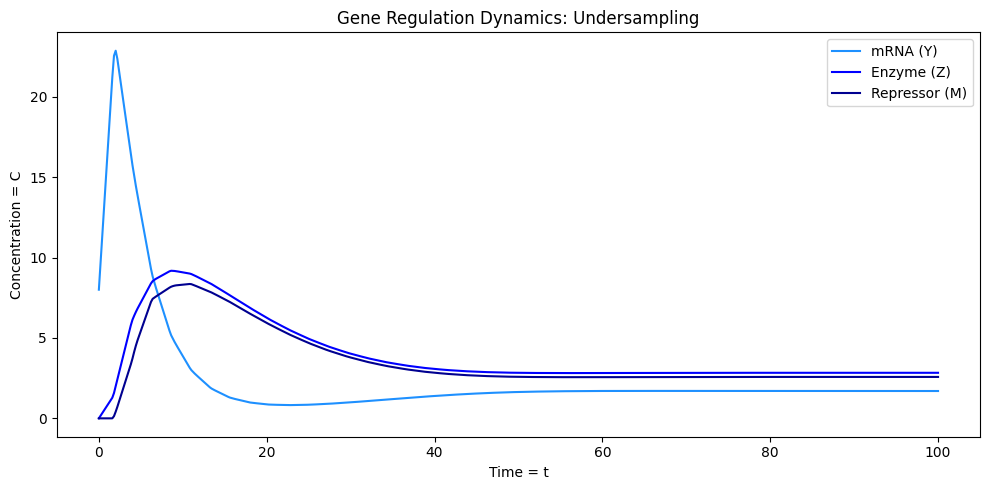

In [2]:
from sys import ps1
import numpy as np
from ddeint import ddeint
import scipy.integrate as intg
import matplotlib.pyplot as plt

# Basic Model

# System of equations
# Y is the state vector function: Y(t) = [mRNA, Enzyme, Repressor]
def current_model(Y, t, c, a, b, k, e, f, T, g, h):
    # Retrieve current values
    y_curr, z_curr, m_curr = Y(t)


    # Define the differential equations
    dYdt = c / (a + b * (m_curr)**1) - k * y_curr
    dZdt = e * y_curr - f * z_curr
    dMdt = g * z_curr - h * m_curr

    return [dYdt, dZdt, dMdt]

# Parameters
#    (. c ,  a  ,  b. ,   k  ,  e  ,  f   ,  T ,   g ,  h )
#p =  (100,  20 , 0.2 ,  0.2 , 0.6 , 0.07 ,  8 , 0.4 , 0.4)
#p =  (100,  30 , 1  ,  1.   , 1.0 , 1.0 ,  1 ,   1 , 1.0)


#p1 = (200, 30, 0.9, 0.6, 0.1, 0.1, 15, 0.05, 0.05)

p1 = (10, 1, 10, 0.22, 0.1, 0.06, 0, 1, 1.1)

# Initial history function (values for t <= 0)
# ddeint needs a function that returns the state for negative time
def values_before_zero(t):
    return np.array([8.0, 0.0, 0.0]) # [Y0, Z0, M0]

# Time points
t_span = np.linspace(0, 100, 500)

# Solve the system
# We use a lambda to pass the parameters 'p' into the model
sol1 = ddeint(current_model, values_before_zero, t_span, fargs=p1)

# 6. Plotting
plt.figure(figsize=(10, 5))
plt.plot(t_span, sol1[:, 0], label='mRNA (Y)', color='#1E90FF', linestyle='-')
plt.plot(t_span, sol1[:, 1], label='Enzyme (Z)', color='#0000FF', linestyle='-')
plt.plot(t_span, sol1[:, 2], label='Repressor (M)', color='#000090', linestyle='-')
plt.legend()
plt.xlabel('Time = t')
plt.ylabel('Concentration = C')
plt.title('Gene Regulation Dynamics: Undersampling')
plt.tight_layout()
plt.savefig('Gene_Regulation_Dynamics_C_Alias.pdf', dpi=600)
plt.show()

Plot device for Basic, Delayed and Hill Coefficient Model

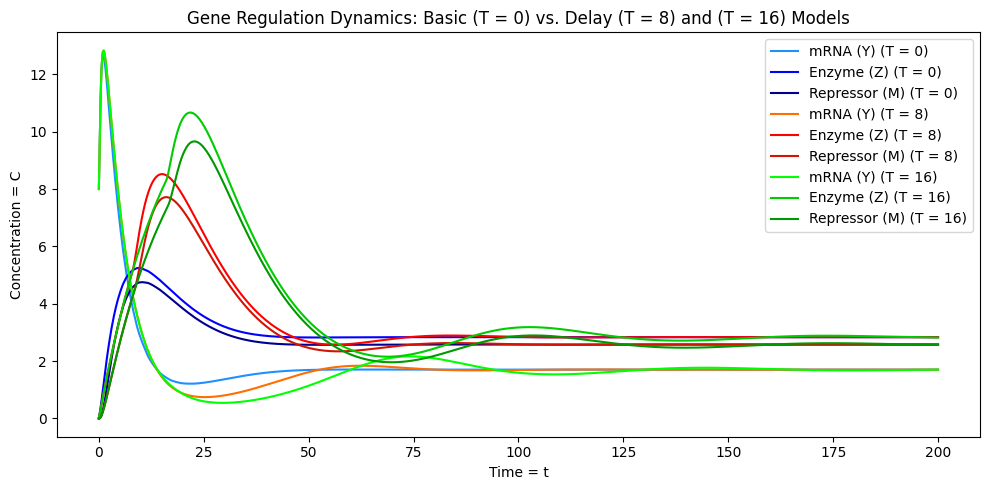

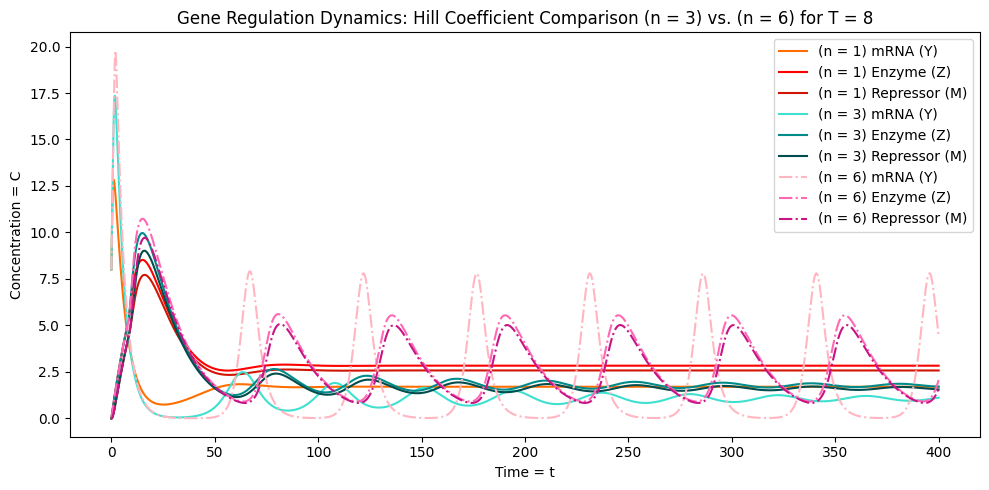

In [28]:
def delay_model(Y, t, c, a, b, k, e, f, T, g, h, n):
    y_curr, z_curr, m_curr = Y(t)
    y_delayed, z_delayed, m_delayed = Y(t - T)

    # Use a Hill function for sharper repression: M^n
    dYdt = c / (a + b * (m_curr**n)) - k * y_curr
    dZdt = e * y_delayed - f * z_curr
    dMdt = g * z_curr - h * m_curr

    return [dYdt, dZdt, dMdt]

# New parameters: Higher delay (T=10) and Hill coefficient (n=4)
#    (c  ,   a ,    b ,   k    ,   e ,  f   ,  T  ,   g ,  h  , n)
#p = (10 ,   1 ,   1  ,  0.2   , 0.2 ,  0.2 ,  8  , 0.2 , 0.2 , 2)
#p =  (200,  30 ,   1  ,  1.4   , 1.0 ,  1.0 ,  4  , 1.0  , 0.9  , 4)


#p2 = (200, 30, 0.9, 0.6, 0.1, 0.1, 15, 0.05, 0.05, 1) #Delay but no HC.
p2 = (10, 1, 10, 0.22, 0.1, 0.06, 1, 1, 1.1, 1)

p24 = (10, 1, 10, 0.22, 0.1, 0.06, 4, 1, 1.1,1)
p28 = (10, 1, 10, 0.22, 0.1, 0.06, 8, 1, 1.1,1)
p22 = (10, 1, 10, 0.22, 0.1, 0.06, 16, 1, 1.1, 1)

#p3 = (200, 30, 0.9, 0.6, 0.1, 0.1, 15, 0.05, 0.05, 2) #Hill Coefficient Active
p3 = (10, 1, 10, 0.22, 0.1, 0.06, 8, 1, 1.1, 3)
p4 = (10, 1, 10, 0.22, 0.1, 0.06, 8, 1, 1.1, 6)

# Time points
t_span = np.linspace(0, 200, 2000)
t_span2 = np.linspace(0, 400, 4000)

# Solve the system
# Pass the parameters 'p' into the model
sol1 = ddeint(current_model, values_before_zero, t_span, fargs=p1) #Basic Implemenation

sol2 = ddeint(delay_model, values_before_zero, t_span2, fargs=p2) #Delay T = 15
sol22 = ddeint(delay_model, values_before_zero, t_span, fargs=p22)
sol24 = ddeint(delay_model, values_before_zero, t_span, fargs=p24)
sol28 = ddeint(delay_model, values_before_zero, t_span, fargs=p28)

sol20 = ddeint(delay_model, values_before_zero, t_span2, fargs=p28)
sol3 = ddeint(delay_model, values_before_zero, t_span2, fargs=p3) #Add Hill Coefficient n = 3
sol4 = ddeint(delay_model, values_before_zero, t_span2, fargs=p4)

#Plot Data
plt.figure(figsize=(10, 5))

# Basic plotted in Redscale

plt.plot(t_span, sol1[:, 0], label='mRNA (Y) (T = 0)',          color='#1E90FF',  linestyle='-')
plt.plot(t_span, sol1[:, 1], label='Enzyme (Z) (T = 0)',          color='#0000FF', linestyle='-')
plt.plot(t_span, sol1[:, 2], label='Repressor (M) (T = 0)',          color='#000090',   linestyle='-')


#Delayed 4,8,16 plotted in Bluescale
'''plt.plot(t_span, sol24[:, 0], label='mRNA (Y) (T = 4)', color='#8A2BE2',  linestyle='-')
plt.plot(t_span, sol24[:, 1], label='Enzyme (Z) (T = 4)', color='#4B0082', linestyle='-')
plt.plot(t_span, sol24[:, 2], label='Repressor (M) (T = 4)', color='#360057',   linestyle='-')'''

plt.plot(t_span, sol28[:, 0], label='mRNA (Y) (T = 8)', color='#FF6E00',  linestyle='-')
plt.plot(t_span, sol28[:, 1], label='Enzyme (Z) (T = 8)', color='#FF0000', linestyle='-')
plt.plot(t_span, sol28[:, 2], label='Repressor (M) (T = 8)', color='#D21404',   linestyle='-')


plt.plot(t_span, sol22[:, 0], label='mRNA (Y) (T = 16)', color='#00FF00',  linestyle='-')
plt.plot(t_span, sol22[:, 1], label='Enzyme (Z) (T = 16)', color='#00CC00', linestyle='-')
plt.plot(t_span, sol22[:, 2], label='Repressor (M) (T = 16)', color='#009900',   linestyle='-')

plt.legend()
plt.xlabel('Time = t')
plt.ylabel('Concentration = C') #(ng/muL)
plt.title('Gene Regulation Dynamics: Basic (T = 0) vs. Delay (T = 8) and (T = 16) Models')
plt.tight_layout()
plt.savefig('Gene_Regulation_Dynamics_C_vs_D.pdf', dpi=600)
plt.show()


# 6. Plotting with Hill Coefficient


plt.figure(figsize=(10, 5))


plt.plot(t_span2, sol20[:, 0], label='(n = 1) mRNA (Y)', color='#FF6E00',  linestyle='-')
plt.plot(t_span2, sol20[:, 1], label='(n = 1) Enzyme (Z)', color='#FF0000', linestyle='-')
plt.plot(t_span2, sol20[:, 2], label='(n = 1) Repressor (M)', color='#D21404',   linestyle='-')


plt.plot(t_span2, sol3[:, 0], label='(n = 3) mRNA (Y)', color='#40E0D0', linestyle='-')
plt.plot(t_span2, sol3[:, 1], label='(n = 3) Enzyme (Z)', color='#008B8B', linestyle='-')
plt.plot(t_span2, sol3[:, 2], label='(n = 3) Repressor (M)', color='#004D4D', linestyle='-')

plt.plot(t_span2, sol4[:, 0], label='(n = 6) mRNA (Y)', color='#FFB6C1', linestyle='-.')
plt.plot(t_span2, sol4[:, 1], label='(n = 6) Enzyme (Z)', color='#FF69B4', linestyle='-.')
plt.plot(t_span2, sol4[:, 2], label='(n = 6) Repressor (M)', color='#C71585', linestyle='-.')
plt.legend()
plt.xlabel('Time = t')
plt.ylabel('Concentration = C')
plt.title('Gene Regulation Dynamics: Hill Coefficient Comparison (n = 3) vs. (n = 6) for T = 8')
plt.tight_layout()
plt.savefig('Gene_Regulation_Dynamics_HC3_vs_HC6.pdf', dpi=600)
plt.show()

In [17]:
#import inspect
#import ddeint
#print(inspect.getsource(ddeint.ddeint))